# GVH `.28.21 SIDE-N3` — Cosmological Candidate \((q_\star,H_\star)\) Map

**Type :** diagnostic numérique minimal.  
**Ne modifie pas la chaîne canonique.**

Objectif :

\[
\boxed{
\text{cartographier le candidat cosmologique homogène vacuum}
\quad
(q_\star,H_\star)
}
\]

déjà dérivé dans `.28.20.7`.

Aucune donnée réelle. Aucune calibration SI. Aucun point de cette carte n'est une prédiction cosmologique validée.

In [1]:
from __future__ import annotations
import json, math, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CANON = {
    "sha256":"d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
    "size":29925,
}
SIDE2 = {
    "sha256":"d50a35ae7ea27560fa8b7e14d50b6448ec6476dde4c8bfb655603e3a2fd9a57c",
    "size":210808,
}

assert CANON["sha256"] == "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4"
assert SIDE2["sha256"] == "d50a35ae7ea27560fa8b7e14d50b6448ec6476dde4c8bfb655603e3a2fd9a57c"

print("Python =",sys.version.split()[0])
print("NumPy =",np.__version__)
print("CANON_GATE = True")
print("SIDE_N2_GATE = True")

Python = 3.13.15
NumPy = 2.1.3
CANON_GATE = True
SIDE_N2_GATE = True


## 1 — Variables dimensionless

On utilise les mêmes variables que SIDE-N2 :

\[
s=\frac{q}{q_+},
\qquad
y=\frac{\alpha H^2}{a},
\qquad
\chi=\frac{\alpha q_+^2}{2M^2}>0.
\]

La contrainte radiale non nulle donne :

\[
\boxed{
y(s)=\frac{(1-s)(3s-1)}{6s}.
}
\]

La condition vacuum couplée pour le candidat homogène est :

\[
\boxed{
G(s;\chi)
=
1-3s+\chi s^2(3-5s)=0.
}
\]

Le candidat recherché satisfait :

\[
\boxed{
\frac13<s_\star<1.
}
\]

In [2]:
def y_of_s(s):
    s = np.asarray(s,dtype=float)
    return (1.0-s)*(3.0*s-1.0)/(6.0*s)

def G(s,chi):
    return 1.0-3.0*s + chi*s*s*(3.0-5.0*s)

def R_vac_residual(s,chi):
    y = y_of_s(s)
    return 3.0*(1.0+chi*s*s)*y/chi - s*(1.0-s)**2

sc = 1.0/math.sqrt(3.0)
yc = (2.0-math.sqrt(3.0))/3.0
chic = 9.0 + 6.0*math.sqrt(3.0)

print("s_c =",sc)
print("y_c =",yc)
print("chi_c =",chic)

s_c = 0.5773502691896258
y_c = 0.08931639747704094
chi_c = 19.392304845413264


## 2 — Unicité du candidat pour \(\chi>0\)

On peut inverser l'équation \(G=0\) :

\[
\boxed{
\chi(s)
=
\frac{3s-1}{s^2(3-5s)}.
}
\]

Pour :

\[
\frac13<s<\frac35,
\]

sa dérivée est :

\[
\boxed{
\frac{d\chi}{ds}
=
\frac{6(5s^2-4s+1)}
{s^3(5s-3)^2}
>0
}
\]

car :

\[
5s^2-4s+1>0
\]

pour tout \(s\).

Donc :

\[
\boxed{
\forall\chi>0,\quad
\exists!\ s_\star(\chi)\in\left(\frac13,\frac35\right).
}
\]

Le scan numérique doit reproduire cette branche unique.

In [3]:
def chi_of_s(s):
    return (3.0*s-1.0)/(s*s*(3.0-5.0*s))

def solve_sstar(chi, n_iter=90):
    lo = 1.0/3.0 + 1e-14
    hi = 3.0/5.0 - 1e-14
    flo = G(lo,chi)
    fhi = G(hi,chi)
    assert flo > 0 and fhi < 0
    for _ in range(n_iter):
        mid = 0.5*(lo+hi)
        fm = G(mid,chi)
        if fm > 0:
            lo = mid
        else:
            hi = mid
    return 0.5*(lo+hi)

for test_chi in [1e-3, 0.1, 1.0, chic, 100.0, 1e3]:
    ss = solve_sstar(test_chi)
    print(f"chi={test_chi:.9g}  s*={ss:.12f}  y*={y_of_s(ss):.12f}")

chi=0.001  s*=0.333382721535  y*=0.000049377227
chi=0.1  s*=0.338325390126  y*=0.004881568643
chi=1  s*=0.386488209564  y*=0.042189053223
chi=19.3923048  s*=0.577350269190  y*=0.089316397477
chi=100  s*=0.595564139491  y*=0.089037884174
chi=1000  s*=0.599555638211  y*=0.088905194261


## 3 — Scan logarithmique du candidat

On balaie uniquement un intervalle numérique prescrit :

\[
\boxed{
10^{-3}\le\chi\le10^3.
}
\]

Ce domaine est un choix de visualisation, pas une plage physique déterminée par GVH.

Pour chaque \(\chi\), on calcule :

\[
s_\star(\chi),
\qquad
y_\star(\chi),
\qquad
h_\star(\chi)=\sqrt{y_\star},
\]

où :

\[
h_\star
=
H_\star\sqrt{\frac{\alpha}{a}}.
\]

In [4]:
chis = np.logspace(-3,3,601)
sstars = np.array([solve_sstar(c) for c in chis])
ystars = y_of_s(sstars)
hstars = np.sqrt(ystars)

Gres = np.array([G(s,c) for s,c in zip(sstars,chis)])
Rres = np.array([R_vac_residual(s,c) for s,c in zip(sstars,chis)])

assert np.all(sstars > 1/3)
assert np.all(sstars < 3/5)
assert np.all(ystars > 0)

print("scan points =",len(chis))
print("s* range =",float(sstars.min()),float(sstars.max()))
print("y* range =",float(ystars.min()),float(ystars.max()))
print("h* range =",float(hstars.min()),float(hstars.max()))
print("max |G| =",float(np.max(np.abs(Gres))))
print("max |R_vac| =",float(np.max(np.abs(Rres))))

scan points = 601
s* range = 0.33338272153533444 0.5995556382109346
y* range = 4.937722725193642e-05 0.0893163846823934
h* range = 0.007026893143625881 0.29885846931682125
max |G| = 2.3880897259687117e-13
max |R_vac| = 1.908473379330644e-13


## 4 — Carte \(s_\star(\chi)\)

Les limites attendues sont :

\[
\chi\to0^+
\quad\Rightarrow\quad
s_\star\to\frac13,
\]

et :

\[
\chi\to+\infty
\quad\Rightarrow\quad
s_\star\to\frac35.
\]

Le fold est rencontré lorsque :

\[
\boxed{
\chi=\chi_c=9+6\sqrt3
}
\]

et :

\[
\boxed{
s_\star=s_c=\frac1{\sqrt3}.
}
\]

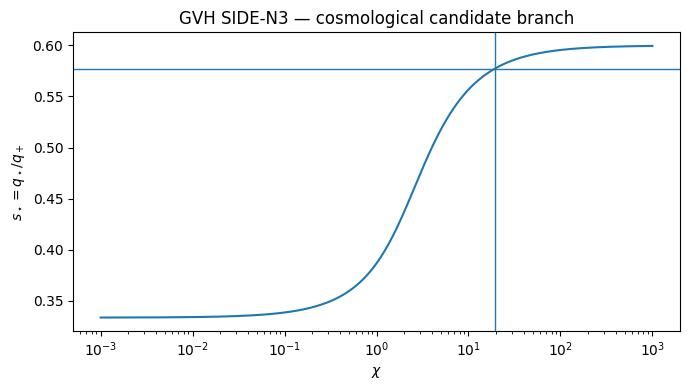

In [5]:
plt.figure(figsize=(7,4))
plt.semilogx(chis,sstars)
plt.axhline(sc,linewidth=1)
plt.axvline(chic,linewidth=1)
plt.xlabel(r"$\chi$")
plt.ylabel(r"$s_\star=q_\star/q_+$")
plt.title("GVH SIDE-N3 — cosmological candidate branch")
plt.tight_layout()
plt.show()

## 5 — Carte \(H_\star\)

La quantité directement représentée est :

\[
\boxed{
h_\star
=
H_\star\sqrt{\frac{\alpha}{a}}
=
\sqrt{y_\star}.
}
\]

Il s'agit d'une fréquence **dimensionless**.

Aucune valeur en s\(^{-1}\) n'est autorisée tant que \(a/\alpha\) n'est pas identifié physiquement.

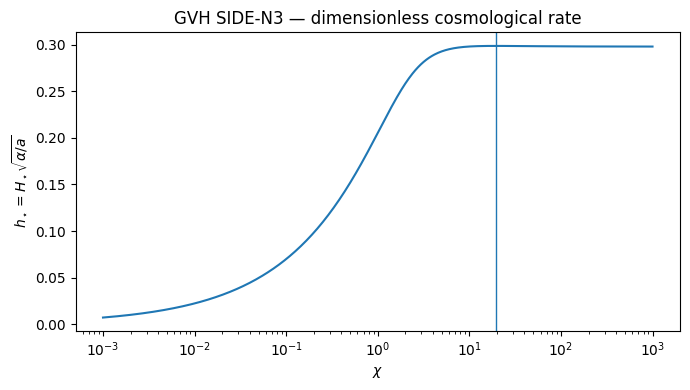

In [6]:
plt.figure(figsize=(7,4))
plt.semilogx(chis,hstars)
plt.axvline(chic,linewidth=1)
plt.xlabel(r"$\chi$")
plt.ylabel(r"$h_\star=H_\star\sqrt{\alpha/a}$")
plt.title("GVH SIDE-N3 — dimensionless cosmological rate")
plt.tight_layout()
plt.show()

## 6 — Position du candidat par rapport au fold

La stabilité radiale à \(H\) fixé est contrôlée par :

\[
\Lambda_{\rm rad}
\propto
U''(q)+3\alpha H^2.
\]

Sur la branche dimensionless :

\[
\boxed{
\Lambda_{\rm rad}(s)
\propto
\frac{3s^2-1}{s}.
}
\]

Donc :

\[
s<s_c
\Rightarrow
\Lambda_{\rm rad}<0
\quad
\text{(racine algébrique instable)},
\]

\[
s=s_c
\Rightarrow
\Lambda_{\rm rad}=0
\quad
\text{(fold)},
\]

\[
s>s_c
\Rightarrow
\Lambda_{\rm rad}>0
\quad
\text{(racine gappée stable dans ce test radial)}.
\]

Le candidat cosmologique change donc de côté exactement à \(\chi_c\).

In [7]:
lambda_rad = (3.0*sstars*sstars-1.0)/sstars

unstable = chis < chic
stable = chis > chic

assert np.all(lambda_rad[unstable] < 0)
assert np.all(lambda_rad[stable] > 0)

scrit_num = solve_sstar(chic)
lcrit = (3*scrit_num*scrit_num-1)/scrit_num

print("s*(chi_c) =",scrit_num)
print("s_c =",sc)
print("Lambda_rad(chi_c) =",lcrit)
print("unstable scan count =",int(np.sum(unstable)))
print("stable scan count =",int(np.sum(stable)))

s*(chi_c) = 0.5773502691896257
s_c = 0.5773502691896258
Lambda_rad(chi_c) = -1.922962686383564e-16
unstable scan count = 429
stable scan count = 172


## 7 — Le fold est le maximum de \(y_\star\)

Comme :

\[
y(s)=\frac{(1-s)(3s-1)}{6s},
\]

on a :

\[
\frac{dy}{ds}=0
\]

à :

\[
s=s_c.
\]

Puisque \(s_\star(\chi)\) est monotone, le candidat satisfait :

\[
\boxed{
y_\star(\chi)\le y_c
}
\]

avec égalité uniquement à :

\[
\boxed{
\chi=\chi_c.
}
\]

Le taux cosmologique dimensionless atteint donc son maximum exactement lorsque le candidat touche le fold.

In [8]:
imax = int(np.argmax(ystars))
chi_ymax = float(chis[imax])
s_ymax = float(sstars[imax])
ymax_grid = float(ystars[imax])

# Exact critical value evaluated separately
s_exact_crit = solve_sstar(chic)
y_exact_crit = float(y_of_s(s_exact_crit))
h_exact_crit = math.sqrt(y_exact_crit)

print("grid chi nearest max =",chi_ymax)
print("grid s at y max =",s_ymax)
print("grid ymax =",ymax_grid)
print("exact y*(chi_c) =",y_exact_crit)
print("exact h*(chi_c) =",h_exact_crit)

assert abs(s_exact_crit-sc) < 1e-12
assert abs(y_exact_crit-yc) < 1e-12
assert np.max(ystars) <= yc + 1e-10

grid chi nearest max = 19.498445997580454
grid s at y max = 0.5774718302730519
grid ymax = 0.0893163846823934
exact y*(chi_c) = 0.0893163974770409
exact h*(chi_c) = 0.2988584907226845


## 8 — Carte paramétrique \((q_\star,H_\star)\)

En unités internes :

\[
\boxed{
\left(
\frac{q_\star}{q_+},
\,
H_\star\sqrt{\frac{\alpha}{a}}
\right)
=
(s_\star,h_\star).
}
\]

La courbe part asymptotiquement de :

\[
\left(\frac13,0\right)
\]

lorsque \(\chi\to0^+\), passe par le fold :

\[
\left(
\frac1{\sqrt3},
\sqrt{\frac{2-\sqrt3}{3}}
\right),
\]

puis tend vers :

\[
\left(
\frac35,
\sqrt{\frac4{45}}
\right)
\]

lorsque \(\chi\to\infty\).

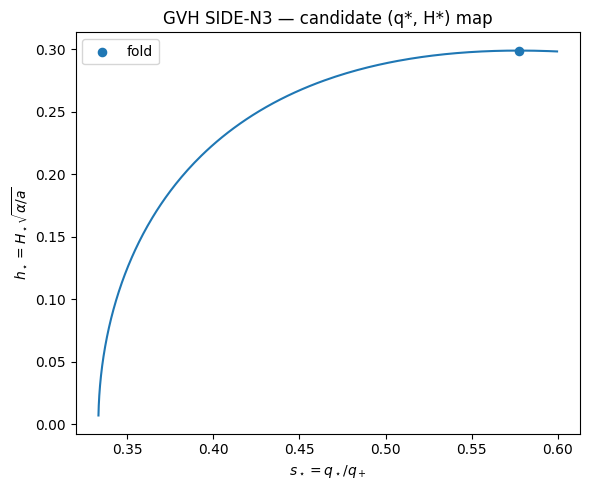

low-chi limiting target: s -> 0.3333333333333333  h -> 0
high-chi limiting target: s -> 0.6  h -> 0.29814239699997197


In [9]:
plt.figure(figsize=(6,5))
plt.plot(sstars,hstars)
plt.scatter([sc],[math.sqrt(yc)],s=35,label="fold")
plt.xlabel(r"$s_\star=q_\star/q_+$")
plt.ylabel(r"$h_\star=H_\star\sqrt{\alpha/a}$")
plt.title("GVH SIDE-N3 — candidate (q*, H*) map")
plt.legend()
plt.tight_layout()
plt.show()

print("low-chi limiting target: s ->",1/3," h -> 0")
print("high-chi limiting target: s ->",3/5," h ->",math.sqrt(4/45))

## 9 — Backreaction effective

Le facteur gravitationnel du minisuperspace est :

\[
M_{\rm eff}^2
=
M^2+\frac{\alpha q^2}{2}.
\]

Sur la carte :

\[
\boxed{
\frac{M_{\rm eff}^2}{M^2}
=
1+\chi s_\star^2.
}
\]

Cette quantité n'est pas calibrée ; elle sert seulement à visualiser combien le candidat s'éloigne du coefficient métrique nu dans le scan choisi.

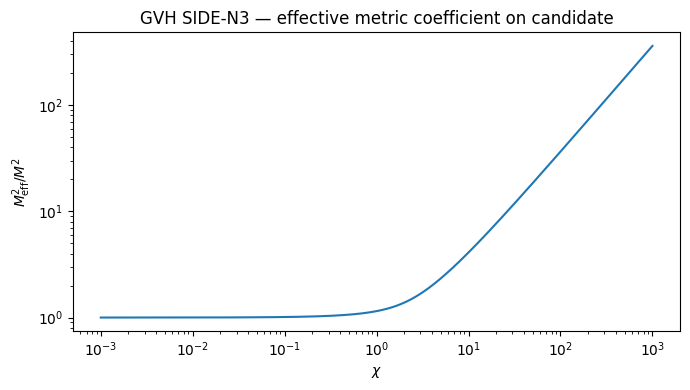

M_eff^2/M^2 scan range = 1.0001111440390182 360.4669633105211


In [10]:
Meff_ratio = 1.0 + chis*sstars*sstars

plt.figure(figsize=(7,4))
plt.loglog(chis,Meff_ratio)
plt.xlabel(r"$\chi$")
plt.ylabel(r"$M_{\rm eff}^2/M^2$")
plt.title("GVH SIDE-N3 — effective metric coefficient on candidate")
plt.tight_layout()
plt.show()

print("M_eff^2/M^2 scan range =",float(Meff_ratio.min()),float(Meff_ratio.max()))

## 10 — Résidus et classification

Pour chaque point du scan, on exige simultanément :

\[
\boxed{
G(s_\star;\chi)=0
}
\]

et la contrainte vacuum :

\[
\boxed{
R(s_\star;\chi)=0.
}
\]

Le statut physique reste :

\[
\boxed{
\textbf{HOMOGENEOUS COSMOLOGICAL SOLUTION CANDIDATE}
}
\]

et non :

\[
\boxed{
\textbf{validated cosmological prediction}.
}
\]

La stabilité perturbative complète, les ghosts anisotropes et l'hyperbolicité restent hors scope de SIDE-N3.

In [11]:
max_G = float(np.max(np.abs(Gres)))
max_R = float(np.max(np.abs(Rres)))

assert max_G < 1e-12
assert max_R < 1e-12

summary = {
    "type":"SIDE_DIAGNOSTIC",
    "canonical_advancement":False,
    "canonical_upstream_sha256":CANON["sha256"],
    "side_N2_sha256":SIDE2["sha256"],
    "scan":{
        "chi_min":float(chis.min()),
        "chi_max":float(chis.max()),
        "points":int(len(chis)),
    },
    "critical":{
        "chi_c":chic,
        "s_c":sc,
        "y_c":yc,
        "h_c":math.sqrt(yc),
    },
    "candidate":{
        "unique_for_all_positive_chi":True,
        "s_interval":"(1/3,3/5)",
        "low_chi_limit_s":1/3,
        "high_chi_limit_s":3/5,
        "high_chi_limit_y":4/45,
        "radial_classification":"unstable for chi<chi_c; fold at chi_c; stable for chi>chi_c",
    },
    "numerical":{
        "s_min":float(sstars.min()),
        "s_max":float(sstars.max()),
        "y_min":float(ystars.min()),
        "y_max_grid":float(ystars.max()),
        "max_abs_G_residual":max_G,
        "max_abs_vacuum_constraint_residual":max_R,
    },
    "locks":{
        "full_perturbative_stability":False,
        "global_ghost_freedom":False,
        "full_hyperbolicity":False,
        "real_data_used":False,
        "SI_calibration_used":False,
    },
    "verdict":{
        "cosmological_candidate_map_materialized":True,
        "candidate_is_prediction":False,
    }
}

print(json.dumps(summary,indent=2))

{
  "type": "SIDE_DIAGNOSTIC",
  "canonical_advancement": false,
  "canonical_upstream_sha256": "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
  "side_N2_sha256": "d50a35ae7ea27560fa8b7e14d50b6448ec6476dde4c8bfb655603e3a2fd9a57c",
  "scan": {
    "chi_min": 0.001,
    "chi_max": 1000.0,
    "points": 601
  },
  "critical": {
    "chi_c": 19.392304845413264,
    "s_c": 0.5773502691896258,
    "y_c": 0.08931639747704094,
    "h_c": 0.29885849072268456
  },
  "candidate": {
    "unique_for_all_positive_chi": true,
    "s_interval": "(1/3,3/5)",
    "low_chi_limit_s": 0.3333333333333333,
    "high_chi_limit_s": 0.6,
    "high_chi_limit_y": 0.08888888888888889,
    "radial_classification": "unstable for chi<chi_c; fold at chi_c; stable for chi>chi_c"
  },
  "numerical": {
    "s_min": 0.33338272153533444,
    "s_max": 0.5995556382109346,
    "y_min": 4.937722725193642e-05,
    "y_max_grid": 0.0893163846823934,
    "max_abs_G_residual": 2.3880897259687117e-13,
    "max_a

## 11 — Verdict SIDE-N3

Le diagnostic matérialise une branche cosmologique vacuum unique :

\[
\boxed{
s_\star(\chi)\in\left(\frac13,\frac35\right)
}
\]

pour tout :

\[
\chi>0.
\]

Elle traverse le fold exactement à :

\[
\boxed{
\chi_c=9+6\sqrt3.
}
\]

Ainsi :

\[
\boxed{
\chi<\chi_c
\Rightarrow
\text{candidat sur la racine radiale instable},
}
\]

\[
\boxed{
\chi=\chi_c
\Rightarrow
\text{candidat au fold},
}
\]

\[
\boxed{
\chi>\chi_c
\Rightarrow
\text{candidat sur la racine gappée stable}
}
\]

dans le seul test radial homogène.

Le maximum de :

\[
H_\star^2\frac{\alpha}{a}
\]

se produit au fold.

**Prochaine application numérique minimale :**

\[
\boxed{
\textbf{SIDE-N4 — cartes d'exclusion anisotropes}.
}
\]

Le canon principal reste `.28.21`; le prochain notebook canonique demeure `.28.21.1`.

In [12]:
export_dir = Path("/content/gvh_exports") if Path("/content").exists() else Path("/mnt/data")
export_dir.mkdir(parents=True,exist_ok=True)

artifact_path = export_dir / (
    "GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N3_"
    "Cosmological_Candidate_qstar_Hstar_Map_FAST.json"
)
artifact_path.write_text(json.dumps(summary,indent=2),encoding="utf-8")
print("artifact =",artifact_path)

artifact = /content/gvh_exports/GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N3_Cosmological_Candidate_qstar_Hstar_Map_FAST.json
